# What are the most demanded skills for the top 3 most popular data roles

In [45]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# loading Data 
from datasets import  load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [46]:
# cleaning data 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [48]:
df_US = df[df['job_country'] == 'United States']

In [49]:
df_skills = df_US.explode('job_skills')

In [50]:
df_skills[['job_title_short','job_skills']]

,job_title_short,job_skills
0,Senior Data Engineer,None
3,Data Engineer,python
3,Data Engineer,c++
3,Data Engineer,java
3,Data Engineer,matlab
...,...,...
785692,Data Scientist,r
785703,Data Analyst,None
785705,Data Analyst,sql
785705,Data Analyst,python


In [51]:
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size()

In [52]:
df_skills_count = df_skills_count.reset_index(name='skill_count')

In [62]:
df_skills_count= df_skills_count.sort_values(by='skill_count',ascending=False)

In [65]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles


['Data Analyst', 'Data Engineer', 'Data Scientist']

**Count of Skills Required for Different Data Job Roles**

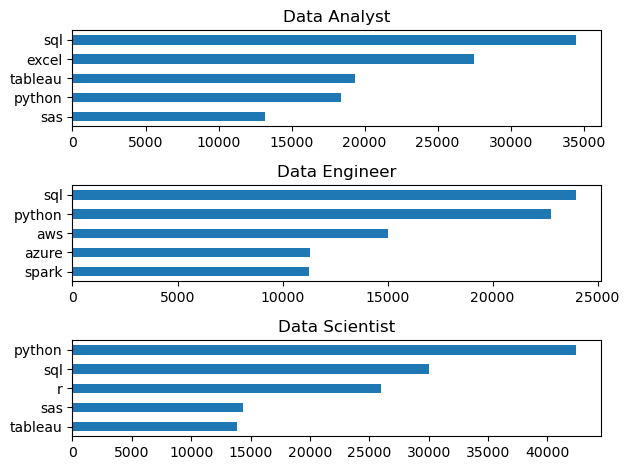

In [67]:
fig ,ax = plt.subplots(len(job_titles),1)
for i , job_title  in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    df_plot.plot(kind="barh",x ='job_skills',y='skill_count',ax = ax[i],title = job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.tight_layout()
plt.show()

In [71]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name="job_total")

In [74]:
df_skill_per = pd.merge(df_skills_count,df_job_title_count,how = 'left',on = 'job_title_short')
df_skill_per['skill_percent'] = (df_skill_per['skill_count']/df_skill_per['job_total'])*100
df_skill_per

,job_skills,job_title_short,skill_count,job_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,clojure,Software Engineer,1,1814,0.055127
1866,vb.net,Senior Data Scientist,1,12946,0.007724
1867,fortran,Machine Learning Engineer,1,921,0.108578
1868,planner,Cloud Engineer,1,423,0.236407


***Percentage of Skills Required for Different Data Job Roles***

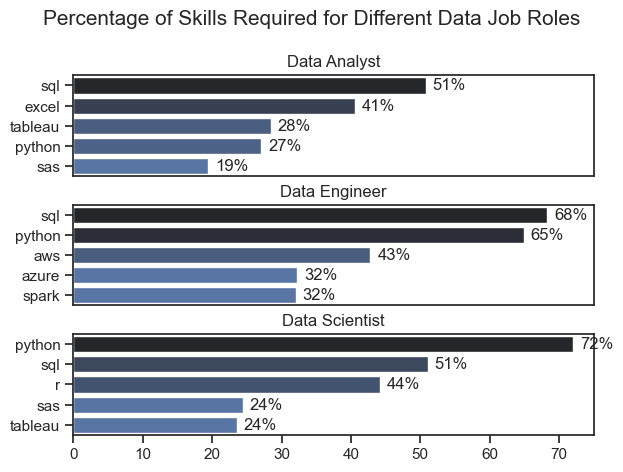

In [112]:
fig ,ax = plt.subplots(len(job_titles),1)
sns.set_theme(style='ticks')
for i , job_title  in enumerate(job_titles):
    df_plot = df_skill_per[df_skill_per['job_title_short']==job_title].head(5)
    sns.barplot(df_plot, y='job_skills',x='skill_percent',ax = ax[i],hue='skill_count',palette="dark:b_r",legend=False)
    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,75)
    
    if(i != len(job_titles)-1):
        ax[i].set_xticks([])
    # ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x ,pos : f"{int(x)}%") )
    for n ,v in enumerate(df_plot['skill_percent']):
        ax[i].text(v+1,n,f"{v:.0f}%",va='center')
fig.suptitle('Percentage of Skills Required for Different Data Job Roles',fontsize = 15)
fig.tight_layout(h_pad=0.5) # Fix the overlaping
plt.show()